# Patch Similarity and PCA

Run all cells to visualize a bundled SAR example with the released DINOSAR ViT-B/16.
Choose a model and image in **Settings**, then rerun from **Build Backbone**.
Weights are loaded from `experiments/weights/` if present; otherwise the notebook
uses the Hugging Face cache or downloads only the selected checkpoint from
[YTang/DINOSAR](https://huggingface.co/YTang/DINOSAR). No login is required.

Start from `DINOSAR/` with `uv sync`, then
`uv run jupyter lab notebooks/patch_similarity_pca.ipynb`.
The notebook also supports CPU execution.


### Setup


In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import patches
from omegaconf import OmegaConf
from PIL import Image

# Locate the package when launched from the repository, package, or notebook directory.
cwd = Path.cwd().resolve()
candidates = [base / sub for base in (cwd, *cwd.parents)
              for sub in ("", "DINOSAR", "DINOSAR_official/DINOSAR")]
repo_root = next((p for p in candidates if (p / "dinosar/configs").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Open this notebook from the DINOSAR repository")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from dinosar.config import resolve_config_path  # noqa: E402
from dinosar.model import load_backbone_from_config  # noqa: E402

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root, device

(PosixPath('/WORKSPACE/Projects/2026_DINOSAR_Pretrain/DINOSAR_official/DINOSAR'),
 device(type='cuda'))

### Settings

Set `model_variant` to `vitb16` (ViT-B, ~341 MB) or `vits16` (ViT-S, ~86 MB).
Leave `checkpoint_path=None` for local lookup and automatic download, or supply
an existing checkpoint path matching the selected model. Downloads use a fixed
release revision and are cached for offline reuse.

Bundled images: `ship.png`, `aircraft.png`, `bridge.png`, `car.png`,
`hoss_0401_s03c1_SAR.tif`, `hoss_0610_s07c2_SAR.tif`, `hoss_0647_s07c2_SAR.tif`.
See [image sources](../dinosar/assets/README.md).


In [4]:
model_variant = "vitb16"
checkpoint_path = None  # Optional: Path("/data/weights/dinosar_b16_unisar7m_60e.pth")
example_image = "hoss_0610_s07c2_SAR.tif"
image_path = repo_root / "dinosar/assets" / example_image  # Or an absolute image path.
target_size = 448
contrast_percentiles = (1, 99.5) if example_image.startswith("hoss_") else None
query_patch_idx = None  # None selects a bright patch; or use an index from the preview.
mean, std = (0.219,), (0.220,)

released_weights = {
    "vits16": "dinosar_s16_unisar7m_60e.pth",
    "vitb16": "dinosar_b16_unisar7m_60e.pth",
}
if model_variant not in released_weights:
    raise ValueError("model_variant must be 'vits16' or 'vitb16'")
model_config_path = f"dinosar/configs/models/dinov3/{model_variant}_reg.yaml"
checkpoint_type = "backbone"


In [5]:
def resolve_checkpoint(local_path, filename):
    if local_path is not None:
        path = Path(local_path).expanduser()
        if not path.is_file():
            raise FileNotFoundError(f"Checkpoint not found: {path}")
        return path
    path = repo_root / "experiments/weights" / filename
    if path.is_file():
        return path
    from huggingface_hub import hf_hub_download
    from huggingface_hub.errors import LocalEntryNotFoundError

    download_args = dict(repo_id="YTang/DINOSAR", filename=filename,
                         revision="159c352055e64dc5703f59254920bc8473870272", token=False)
    try:
        return Path(hf_hub_download(**download_args, local_files_only=True))
    except LocalEntryNotFoundError:
        print(f"Downloading {filename} from YTang/DINOSAR …")
        return Path(hf_hub_download(**download_args))


def load_model_config(model_config_path: str | Path):
    resolved_path = resolve_config_path(model_config_path)
    config = OmegaConf.load(resolved_path)
    model_config = OmegaConf.to_container(config.model, resolve=True)
    if not isinstance(model_config, dict):
        raise TypeError(f"Expected a model config mapping, got {type(model_config)!r}")
    return resolved_path, model_config


def build_backbone(model_config_path: str | Path, checkpoint_path: Path, checkpoint_type: str):
    resolved_model_config_path, model_config = load_model_config(model_config_path)
    backbone = load_backbone_from_config(model_config, checkpoint_path, checkpoint_type=checkpoint_type, strict=True)
    backbone = backbone.to(device)
    backbone.eval()
    return backbone, model_config, {"model_config_path": resolved_model_config_path}


def resolve_patch_size(patch_size):
    if isinstance(patch_size, tuple):
        if patch_size[0] != patch_size[1]:
            raise ValueError(f"Expected square patch size, got {patch_size}")
        patch_size = patch_size[0]
    return int(patch_size)


def load_image_tensor(
    image_path: Path,
    target_size: int,
    patch_size: int,
    mean: tuple[float, ...],
    std: tuple[float, ...],
    contrast_percentiles=None,
):
    patch_size = resolve_patch_size(patch_size)
    if target_size % patch_size != 0:
        raise ValueError(f"target_size={target_size} must be divisible by patch_size={patch_size}")

    with Image.open(image_path) as source:
        if contrast_percentiles is None:
            image = source.convert("L")
        else:
            # Preserve floating-point SAR intensities until after contrast scaling.
            values = np.asarray(source if source.mode in ("F", "I") else source.convert("L"), dtype=np.float32)
            values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
            low, high = np.percentile(values, contrast_percentiles)
            values = np.clip((values - low) / max(high - low, 1e-6), 0, 1)
            image = Image.fromarray((values * 255).round().astype(np.uint8))

    raw_width, raw_height = image.size
    scale = target_size / max(raw_width, raw_height)
    resized_width = max(1, round(raw_width * scale))
    resized_height = max(1, round(raw_height * scale))
    image_resized = image.resize((resized_width, resized_height), resample=Image.BICUBIC)

    prepared_width = ((resized_width + patch_size - 1) // patch_size) * patch_size
    prepared_height = ((resized_height + patch_size - 1) // patch_size) * patch_size
    image_prepared = Image.new("L", (prepared_width, prepared_height))
    image_prepared.paste(image_resized, (0, 0))

    image_np = np.array(image_prepared, dtype=np.float32) / 255.0
    image_tensor = torch.from_numpy(image_np).unsqueeze(0)
    mean_t = torch.tensor(mean, dtype=image_tensor.dtype).view(-1, 1, 1)
    std_t = torch.tensor(std, dtype=image_tensor.dtype).view(-1, 1, 1)
    image_tensor = ((image_tensor - mean_t) / std_t).unsqueeze(0)
    image_info = {
        "content_size": image_resized.size,
        "prepared_size": image_prepared.size,
        "grid_shape": (prepared_height // patch_size, prepared_width // patch_size),
        "patch_size": patch_size,
    }
    return image, image_prepared, image_tensor, image_info


def patch_row_col_from_index(patch_index: int, grid_shape: tuple[int, int]):
    grid_h, grid_w = grid_shape
    if not (0 <= patch_index < grid_h * grid_w):
        raise ValueError(f"Patch index out of bounds: {patch_index} for grid {grid_h}x{grid_w}")
    return patch_index // grid_w, patch_index % grid_w


def draw_patch_grid(
    ax,
    image_size: tuple[int, int],
    grid_shape: tuple[int, int],
    *,
    selected_patch_idx: int | None = None,
    highlight_indices: list[int] | None = None,
    annotate_indices: bool = False,
):
    width, height = image_size
    grid_h, grid_w = grid_shape
    cell_w = width / grid_w
    cell_h = height / grid_h
    highlight_index_set = set([] if highlight_indices is None else highlight_indices)
    for row in range(grid_h):
        for col in range(grid_w):
            patch_idx = row * grid_w + col
            is_selected = patch_idx == selected_patch_idx
            is_highlight = patch_idx in highlight_index_set
            edgecolor = "red" if is_selected else ("deepskyblue" if is_highlight else "white")
            linewidth = 2.0 if is_selected else (1.3 if is_highlight else 0.6)
            alpha = 1.0 if (is_selected or is_highlight) else 0.35
            ax.add_patch(
                patches.Rectangle(
                    (col * cell_w, row * cell_h),
                    cell_w,
                    cell_h,
                    linewidth=linewidth,
                    edgecolor=edgecolor,
                    facecolor="none",
                    alpha=alpha,
                )
            )
            if annotate_indices:
                ax.text(
                    col * cell_w + cell_w / 2,
                    row * cell_h + cell_h / 2,
                    str(patch_idx),
                    color="red" if is_selected else "white",
                    fontsize=6,
                    ha="center",
                    va="center",
                    bbox={"facecolor": "black", "alpha": 0.25, "pad": 0.8, "edgecolor": "none"},
                )


def draw_selected_patch_on_raw_image(ax, raw_image_size: tuple[int, int], image_info: dict, selected_patch_idx: int):
    content_width, content_height = image_info["content_size"]
    patch_size = image_info.get("patch_size")
    if patch_size is None:
        grid_h, grid_w = image_info["grid_shape"]
        if content_width % grid_w == 0:
            patch_size = content_width // grid_w
        elif content_height % grid_h == 0:
            patch_size = content_height // grid_h
        else:
            raise KeyError("patch_size")
    row, col = patch_row_col_from_index(selected_patch_idx, image_info["grid_shape"])
    x0 = col * patch_size
    y0 = row * patch_size
    if x0 >= content_width or y0 >= content_height:
        return False

    x1 = min(x0 + patch_size, content_width)
    y1 = min(y0 + patch_size, content_height)
    raw_width, raw_height = raw_image_size
    ax.add_patch(
        patches.Rectangle(
            (x0 * raw_width / content_width, y0 * raw_height / content_height),
            (x1 - x0) * raw_width / content_width,
            (y1 - y0) * raw_height / content_height,
            linewidth=2.0,
            edgecolor="red",
            facecolor="none",
        )
    )
    return True


def compute_patch_similarity(backbone, image_tensor: torch.Tensor, selected_patch_idx: int, image_info: dict):
    patch_size = resolve_patch_size(backbone.patch_size)
    _, _, input_height, input_width = image_tensor.shape
    if input_height % patch_size != 0 or input_width % patch_size != 0:
        raise ValueError(
            f"image tensor shape {(input_height, input_width)} must be divisible by patch_size={patch_size}"
        )

    grid_shape = (input_height // patch_size, input_width // patch_size)
    if image_info["grid_shape"] != grid_shape:
        raise ValueError(f"image_info grid {image_info['grid_shape']} does not match tensor grid {grid_shape}")

    row, col = patch_row_col_from_index(selected_patch_idx, grid_shape)
    with torch.inference_mode():
        features = backbone.forward_features(image_tensor.to(device))
        patch_tokens = torch.nn.functional.normalize(features["x_norm_patchtokens"][0], dim=-1)
        reference_token = patch_tokens[selected_patch_idx]
        similarity = patch_tokens @ reference_token
    similarity_map = similarity.view(*grid_shape).cpu().numpy()
    return {
        "row": row,
        "col": col,
        "grid_shape": grid_shape,
        "patch_index": selected_patch_idx,
        "similarity": similarity.cpu(),
        "similarity_map": similarity_map,
        "features": features,
        "image_info": image_info,
    }


def get_topk_patch_indices(similarity_result: dict, topk: int):
    similarity = similarity_result["similarity"].clone()
    selected_patch_idx = similarity_result["patch_index"]
    topk = max(int(topk), 0)
    if topk == 0:
        return []
    similarity[selected_patch_idx] = -torch.inf
    k = min(topk, similarity.numel() - 1)
    return similarity.topk(k).indices.tolist()


def plot_patch_overview(
    raw_image: Image.Image, image_prepared: Image.Image, similarity_result: dict, topk_indices: list[int]
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(raw_image, cmap="gray")
    has_raw_patch = draw_selected_patch_on_raw_image(
        axes[0],
        raw_image.size,
        similarity_result["image_info"],
        similarity_result["patch_index"],
    )
    raw_title = (
        f"Raw image patch {similarity_result['patch_index']}"
        if has_raw_patch
        else f"Raw image (patch {similarity_result['patch_index']} is in padded area)"
    )
    axes[0].set_title(raw_title)
    axes[0].axis("off")

    axes[1].imshow(image_prepared, cmap="gray")
    draw_patch_grid(
        axes[1],
        image_prepared.size,
        similarity_result["grid_shape"],
        selected_patch_idx=similarity_result["patch_index"],
        highlight_indices=topk_indices,
        annotate_indices=False,
    )
    axes[1].set_title("Prepared image with top-k matches")
    axes[1].axis("off")

    axes[2].imshow(similarity_result["similarity_map"], cmap="viridis", vmin=0, vmax=1, aspect="equal")
    axes[2].set_title("Patch cosine similarity")
    axes[2].axis("off")

    fig.tight_layout()
    return fig, axes

### Build Backbone

Re-run this cell only when you change the model config or checkpoint.


In [6]:
resolved_checkpoint = resolve_checkpoint(checkpoint_path, released_weights[model_variant])

backbone, model_config, load_report = build_backbone(
    model_config_path=model_config_path,
    checkpoint_path=resolved_checkpoint,
    checkpoint_type=checkpoint_type,
)

_ckpt = resolved_checkpoint.resolve()
try:
    _ckpt_display = _ckpt.relative_to(repo_root)
except ValueError:
    _ckpt_display = _ckpt

print("model config:", load_report["model_config_path"].relative_to(repo_root))
print("checkpoint:", _ckpt_display)
print("checkpoint_type:", checkpoint_type)
print("patch_size:", backbone.patch_size)
print("embed_dim:", backbone.embed_dim)
print("num_register_tokens:", model_config.get("num_register_tokens", 0))
print("device:", device)

dinosar_b16_unisar7m_60e.pth:   0%|          | 0.00/341M [00:00<?, ?B/s]

model config: dinosar/configs/models/dinov3/vitb16_reg.yaml
checkpoint: /home/yan/.cache/huggingface/hub/models--YTang--DINOSAR/blobs/ef975a3398c9ac6d8fe9df9904a1939a47912453493d94f17643724981e59a19
checkpoint_type: backbone
patch_size: 16
embed_dim: 768
num_register_tokens: 4
device: cuda


### Image Inputs

Preview the prepared input and patch indices. The next cell uses a bright patch
automatically; set `query_patch_idx` in Settings to select one manually.
For custom images, set `image_path` and choose whether to apply `contrast_percentiles`.


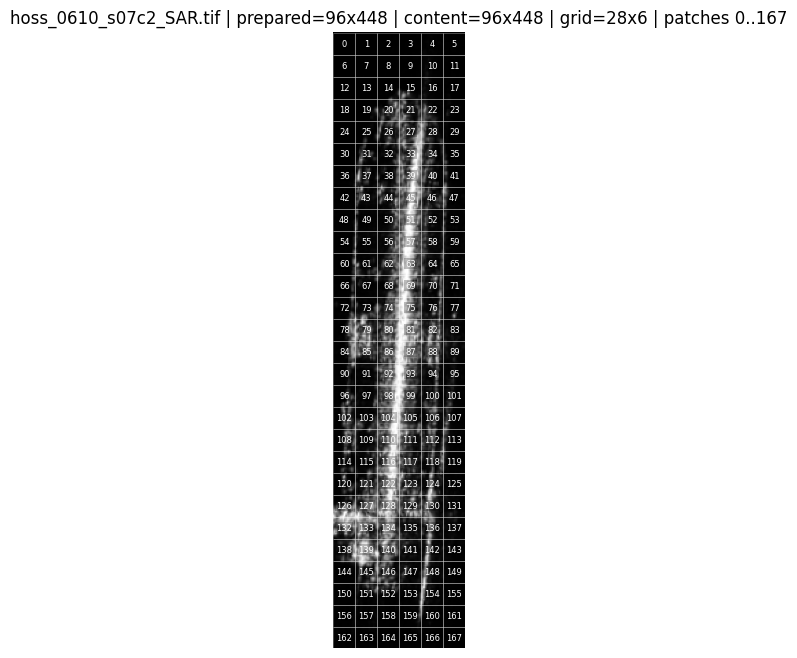

raw image size: (85, 398)
resized content size: (96, 448)
model input (prepared): (96, 448)
grid: 28x6 | valid patch index range: (0, 167)


In [7]:
patch_size = resolve_patch_size(backbone.patch_size)
raw_image, image_prepared, image_tensor, image_info = load_image_tensor(
    image_path,
    target_size,
    patch_size,
    mean,
    std,
    contrast_percentiles=contrast_percentiles,
)
grid_shape = image_info["grid_shape"]
grid_h, grid_w = grid_shape

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_prepared, cmap="gray")
draw_patch_grid(ax, image_prepared.size, grid_shape, annotate_indices=True)
ax.set_title(
    f"{image_path.name} | prepared={image_info['prepared_size'][0]}x{image_info['prepared_size'][1]} | "
    f"content={image_info['content_size'][0]}x{image_info['content_size'][1]} | "
    f"grid={grid_h}x{grid_w} | patches 0..{grid_h * grid_w - 1}"
)
ax.axis("off")
plt.show()

print("raw image size:", raw_image.size)
print("resized content size:", image_info["content_size"])
print("model input (prepared):", image_info["prepared_size"])
print("grid:", f"{grid_h}x{grid_w}", "| valid patch index range:", (0, grid_h * grid_w - 1))

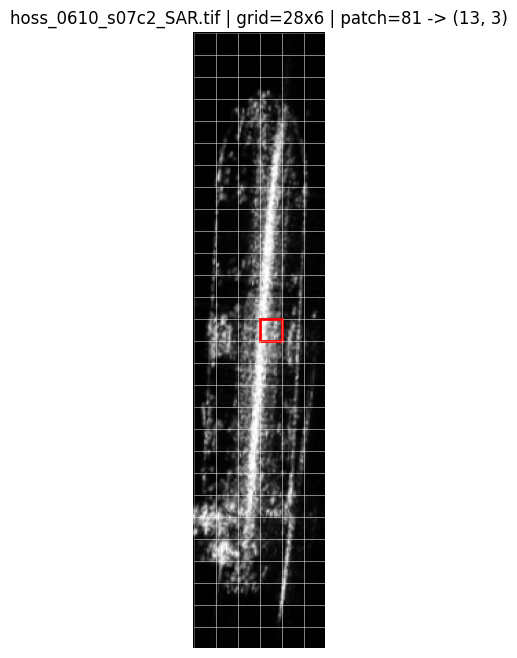

selected patch row/col: (13, 3)


In [9]:
selected_patch_idx = query_patch_idx
if selected_patch_idx is None:
    pixels = np.asarray(image_prepared, dtype=np.float32)
    gh, gw = image_info["grid_shape"]
    patch_means = pixels.reshape(gh, patch_size, gw, patch_size).mean(axis=(1, 3))
    selected_patch_idx = int(patch_means.argmax())
annotate_patch_indices = False
topk_patches = 25

grid_shape = image_info["grid_shape"]
grid_h, grid_w = grid_shape
row, col = patch_row_col_from_index(selected_patch_idx, grid_shape)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_prepared, cmap="gray")
draw_patch_grid(
    ax,
    image_prepared.size,
    grid_shape,
    selected_patch_idx=selected_patch_idx,
    annotate_indices=annotate_patch_indices,
)
ax.set_title(f"{image_path.name} | grid={grid_h}x{grid_w} | patch={selected_patch_idx} -> ({row}, {col})")
ax.axis("off")
plt.show()

print("selected patch row/col:", (row, col))

### Similarity Analysis


In [10]:
similarity_result = compute_patch_similarity(
    backbone=backbone,
    image_tensor=image_tensor,
    selected_patch_idx=selected_patch_idx,
    image_info=image_info,
)
topk_indices = get_topk_patch_indices(similarity_result, topk=topk_patches)

print("feature tensor shape:", tuple(similarity_result["features"]["x_norm_patchtokens"].shape))
print("selected patch row/col:", (similarity_result["row"], similarity_result["col"]))
print("top-k similar patch indices:", topk_indices)

feature tensor shape: (1, 168, 768)
selected patch row/col: (13, 3)
top-k similar patch indices: [75, 69, 87, 63, 57, 122, 51, 110, 45, 116, 128, 104, 93, 98, 39, 99, 86, 92, 134, 105, 58, 52, 64, 80, 142]


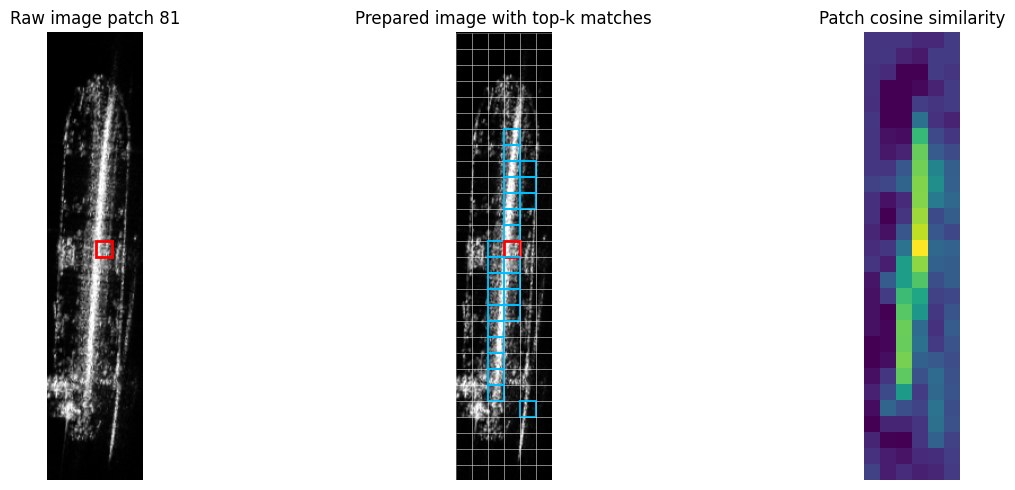

In [11]:
fig, _ = plot_patch_overview(
    raw_image=raw_image,
    image_prepared=image_prepared,
    similarity_result=similarity_result,
    topk_indices=topk_indices,
)
plt.show()

### Similarity + PCA

Adapted from the paper's HOSS visualization: highlight patches with cosine similarity
≥ `similarity_threshold` (excluding the query), then show similarity and PCA colors.
This reuses `similarity_result`; no additional model forward pass is needed.

PCA uses the unmodified `x_norm_patchtokens`, three whitened components, and
per-channel 1st–99th percentile scaling, as in the original script. Colors are
fitted separately for each image and do not represent semantic classes.
The input follows this notebook's aspect-preserving resize and patch-aligned padding;
the original HOSS script instead resizes to 128 × 512 (width × height).
Bundled HOSS examples use 1st–99.5th percentile contrast scaling before resizing.


In [12]:
from sklearn.decomposition import PCA


def plot_similarity_pca(image_prepared, similarity_result, similarity_threshold=0.3):
    if not -1 <= similarity_threshold <= 1:
        raise ValueError("similarity_threshold must be between -1 and 1")
    grid_shape = similarity_result["grid_shape"]
    tokens = similarity_result["features"]["x_norm_patchtokens"][0].detach().float().cpu().numpy()
    if tokens.shape[0] != np.prod(grid_shape) or min(tokens.shape) < 3:
        raise ValueError("PCA requires at least three patch tokens matching the image grid")
    pca = PCA(n_components=3, whiten=True, random_state=0)
    projected = pca.fit_transform(tokens)
    low, high = np.percentile(projected, [1, 99], axis=0)
    rgb = np.clip((projected - low) / np.maximum(high - low, 1e-6), 0, 1)
    pca_image = Image.fromarray((rgb.reshape(*grid_shape, 3) * 255).round().astype(np.uint8))
    pca_image = pca_image.resize(image_prepared.size, Image.Resampling.NEAREST)

    similarities = similarity_result["similarity"].clone()
    similarities[similarity_result["patch_index"]] = -torch.inf
    matches = torch.where(similarities >= similarity_threshold)[0].tolist()
    width, height = image_prepared.size
    extent = (0, width, height, 0)
    with plt.rc_context({"font.size": 11, "text.color": "#2D2D2D", "figure.facecolor": "#F9F8F5"}):
        fig, axes = plt.subplots(1, 3, figsize=(10, 5), layout="constrained")
        axes[0].imshow(image_prepared, cmap="gray", extent=extent)
        draw_patch_grid(axes[0], image_prepared.size, grid_shape,
                        selected_patch_idx=similarity_result["patch_index"], highlight_indices=matches)
        axes[0].set_title(f"Query + matches (≥ {similarity_threshold:g})")
        heatmap = axes[1].imshow(similarity_result["similarity_map"], cmap="viridis",
                                 vmin=0, vmax=1, interpolation="nearest", extent=extent)
        axes[1].set_title("Cosine similarity")
        fig.colorbar(heatmap, ax=axes[1], shrink=0.6, ticks=[0, 0.5, 1])
        axes[2].imshow(pca_image, extent=extent, interpolation="nearest")
        axes[2].set_title("Patch feature PCA")
        for ax in axes:
            ax.set_xlim(0, width)
            ax.set_ylim(height, 0)
            ax.set_axis_off()
    return fig, pca.explained_variance_ratio_


PCA explained variance (PC1–PC3): [0.158 0.132 0.097]


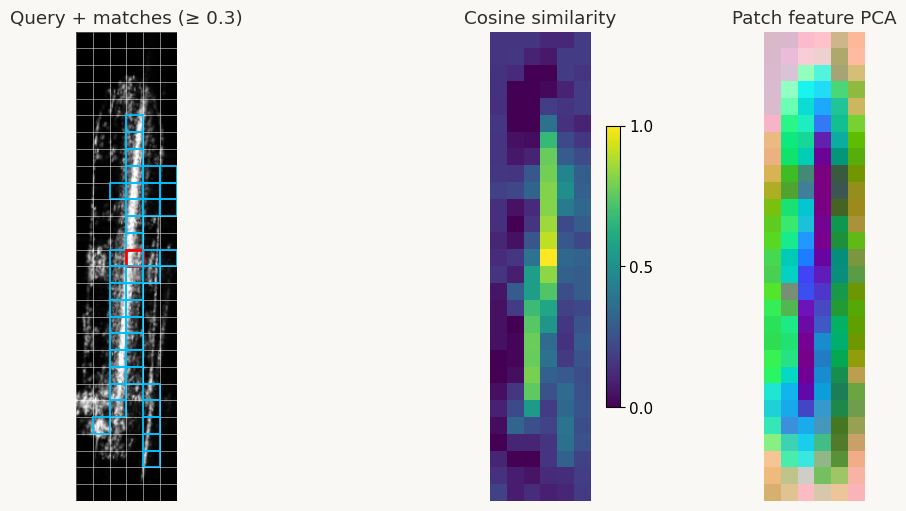

In [13]:
similarity_threshold = 0.3
output_stem = None  # e.g. repo_root / "experiments/visualizations/ship_similarity_pca"

pca_figure, explained_variance = plot_similarity_pca(
    image_prepared, similarity_result, similarity_threshold
)
print("PCA explained variance (PC1–PC3):", np.round(explained_variance, 3))
if output_stem is not None:
    output_stem = Path(output_stem)
    output_stem.parent.mkdir(parents=True, exist_ok=True)
    for suffix in (".png", ".pdf"):
        pca_figure.savefig(output_stem.with_suffix(suffix), dpi=300, bbox_inches="tight")
plt.show()
